In [248]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260430'
__datasets__ = ['SDSS-V LVM DRPALL, DAPALL, QC_BITMASK']  
__keywords__ = ['Quality control']

# SDSS-V LVM DR20 quality-control bitmask tutorial

This notebook shows how to read the DR20 `drpall`, `dapall`, and `qcall` summary products, merge them into a single table, and decode the packed `qa_bitmask` values into human-readable quality flags for science selection.


## Required Python dependencies

The next cells import the standard scientific Python stack used throughout the tutorial, including `astropy` for FITS tables and `matplotlib` for sky visualizations.


In [249]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table,join
import matplotlib.colors as mpl_colors
from matplotlib import rcParams as rc
rc.update({'font.size': 19,\
           'font.weight': 900,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 19,\
           'ytick.labelsize' : 19,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits

# Import the sdss_access package to get the data
from typing import Iterable, List, Sequence, Tuple

# Tools for downloading the RSP templates
import gdown 
from pathlib import Path

from sdss_access import Access
access = Access(release='dr20', verbose=True)

import warnings

warnings.simplefilter("ignore")

In [250]:
#####################################################
# Patch for non delivered dataset, still under Tree
#####################################################
#from tree import Tree
# Once the data is delivered
from sdss_access import Access

try:
    #################################################
    # For already delivered datasets, in DR20
    #################################################
    
    access = Access(release='dr20', verbose=True)
except:
    ##################################################
    # For not yet delivered datasets, still under Tree
    ##################################################
    from tree import Tree
    #from sdss_access import Access
    tree = Tree(config = 'dr20')
    #tree = Tree(config = 'dr20')
    access = Access(release='dr20', verbose=True)

# ---


## 1. Access the DR20 summary products

This section prepares file access to the DR20 summary tables. Depending on the environment, the products may be downloaded through SDSS tools or opened from a local directory.


In [251]:
#
# SDSS access of files
#

## 2. Load the `drpall`, `dapall`, and QA summary tables

Here the tutorial opens the DRP, DAP, and QA bitmask FITS files and converts the relevant extensions into `astropy` tables for later merging.


In [252]:
# Local directory 
dir_tables = 'dr20_tables/'
# -rw-rw-r-- 1 sanchez sanchez 135360 abr 30 11:22 dr20_tables/drpall-1.2.0.fits
# -rw-rw-r-- 1 sanchez sanchez 100800 abr 30 11:22 dr20_tables/dapall-1.2.0-1.2.0.251218.fits
# -rw-r--r-- 1 sanchez sanchez  51840 abr 30 11:23 dr20_tables/qa_bitmasks-1.2.0-1.2.0.251218.fits

hdu_drpall = fits.open(f'{dir_tables}/drpall-1.2.0.fits')
hdu_dapall = fits.open(f'{dir_tables}/dapall-1.2.0-1.2.0.251218.fits')
hdu_qa_bitmask = fits.open(f'{dir_tables}/qa_bitmasks-1.2.0-1.2.0.251218.fits')

tab_drpall = Table(hdu_drpall[1].data)
tab_dapall = Table(hdu_dapall[1].data)
tab_qa_bitmask = Table(hdu_qa_bitmask[1].data)

print(len(tab_drpall))
print(len(tab_dapall))
print(len(tab_qa_bitmask))

169
169
169


## 3. Build a combined summary table

The three summary tables are joined into a single catalog keyed by exposure identifiers. This combined table is the main working product for the rest of the notebook.


In [253]:
tab_all = join(tab_drpall,tab_dapall,keys=['expnum','tilegrp','mjd','exptime','tileid'])
print(len(tab_all))
tab_all = join(tab_all,tab_qa_bitmask,keys=['expnum','mjd','tileid'],join_type='left')
print(len(tab_all))
tab_all.rename_column('ra_1','ra') 
tab_all.rename_column('dec_1','dec')
tab_all.remove_columns(['ra_2','dec_2'])
 

169
169


## 4. Helper to inspect available columns

The merged table contains many DRP, DAP, and QA columns. This helper formats long column lists into readable blocks so it is easier to discover useful quantities.


In [254]:

def list_columns(obj, cols=4, columnwise=True, gap=2):
    """
    Print the given list in evenly-spaced columns.

    Parameters
    ----------
    obj : list
        The list to be printed.
    cols : int
        The number of columns in which the list should be printed.
    columnwise : bool, default=True
        If True, the items in the list will be printed column-wise.
        If False the items in the list will be printed row-wise.
    gap : int
        The number of spaces that should separate the longest column
        item/s from the next column. This is the effective spacing
        between columns based on the maximum len() of the list items.
    """

    sobj = [str(item) for item in obj]
    if cols > len(sobj): cols = len(sobj)
    max_len = max([len(item) for item in sobj])
    if columnwise: cols = int(math.ceil(float(len(sobj)) / float(cols)))
    plist = [sobj[i: i+cols] for i in range(0, len(sobj), cols)]
    if columnwise:
        if not len(plist[-1]) == cols:
            plist[-1].extend(['']*(len(sobj) - len(plist[-1])))
        plist = zip(*plist)
    printer = '\n'.join([
        ''.join([c.ljust(max_len + gap) for c in p])
        for p in plist])
    print(printer)


class scatter():
    def __init__(self,x,y,ax,size=1,**kwargs):
        self.n = len(x)
        self.ax = ax
        self.ax.figure.canvas.draw()
        self.size_data=size
        self.size = size
        self.sc = ax.scatter(x,y,s=self.size,**kwargs)
        self._resize()
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self._resize)

    def _resize(self,event=None):
        ppd=72./self.ax.figure.dpi
        trans = self.ax.transData.transform
        s =  ((trans((1,self.size_data))-trans((0,0)))*ppd)[1]
        if s != self.size:
            self.sc.set_sizes(s**2*np.ones(self.n))
            self.size = s
            self._redraw_later()

    def _redraw_later(self):
        self.timer = self.ax.figure.canvas.new_timer(interval=10)
        self.timer.single_shot = True
        self.timer.add_callback(lambda : self.ax.figure.canvas.draw_idle())
        self.timer.start()
        


def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma





## 5. Define a helper to build RGB maps from DAP quantities

This plotting helper combines three emission-line measurements into an RGB sky map, which is useful for visually exploring the survey footprint and comparing regions with different spectral properties.


In [255]:
def map_plot_DAP_rgb(tab_DAP,\
                     rgb_key=('flux_pe_6583.45','flux_pe_6562.85','flux_pe_5006.84'), \
                     rgb_scale=(1.0,1.0,1.0),\
                 vmin=0, vmax=0, titles=('r','g','b'), filename='junk',\
                fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,fs=18):

    rc.update({'font.size': fs*fsize/5,\
               'font.weight': 900,\
               'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : fs*fsize/5,\
               'ytick.labelsize' : fs*fsize/5,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6,\
               'ytick.major.size'        :   6,\
               'xtick.minor.size'        :   3,\
               'ytick.minor.size'        :   3,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X= tab_DAP['ra'].value
    Y= tab_DAP['dec'].value
    R=tab_DAP[rgb_key[2]].value  
    G=tab_DAP[rgb_key[1]].value    
    B=tab_DAP[rgb_key[0]].value 
    R = R * rgb_scale[0]
    G = G * rgb_scale[1]
    B = B * rgb_scale[2]
    RGB = np.stack((R, G, B), axis=1)
    if (vmin==vmax):
        vmin=np.nanmin(RGB)
        vmax=np.nanmax(RGB)
    print(f'min/max:{vmin}/{vmax}')
    r = (R-vmin)/(vmax-vmin)
    g = (G-vmin)/(vmax-vmin)
    b = (B-vmin)/(vmax-vmin)

    r[r>1]=1
    r[r<0]=0
    b[b>1]=1
    b[b<0]=0
    r[r>1]=1
    r[r<0]=0    
    
    r = np.ma.filled(r, fill_value=0.0)
    g = np.ma.filled(g, fill_value=0.0)
    b = np.ma.filled(b, fill_value=0.0)

    r=r**gamma
    g=g**gamma
    b=b**gamma
    
#    print (r)
    r = np.ma.compressed(r)
    g = np.ma.compressed(g)
    b = np.ma.compressed(b)   


    #print(r,g,b)
    colors = np.stack((r, g, b), axis=1)
    colors[colors>1]=1
    colors[colors<0]=0
#    print(colors)
    fig,ax = plt.subplots(1,1,figsize=(fsize,fsize*0.95))
#    norm=mpl_colors.PowerNorm(vmin=0,vmax=1,gamma=gamma)
    scatter(X, Y, ax, color=colors, size=sf*35.6/3600, marker='h',edgecolors='black')#, color=colors)
    
    ax.set_xlabel('Ra [deg]')#,fontsize=21)
    ax.set_ylabel('Dec [deg]')#,fontsize=21)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.06*(yy[1]-yy[0]),titles[0],fontsize=fs*(fsize/5),color='tomato')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.12*(yy[1]-yy[0]),titles[1],fontsize=fs*(fsize/5),color='forestgreen')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.18*(yy[1]-yy[0]),titles[2],fontsize=fs*(fsize/5),color='steelblue')

    if (tab_pt != None):
        for tap_pt_now in tab_pt:
            ax.text(tab_pt['ra'],tab_pt['dec'],tab_pt['id'])
#    ax.set_aspect('equal', adjustable='box')
    try:
        plt.show()
    except:
        plt_show=False
    fig.tight_layout()
    fig.savefig(f'{figs_dir}/{filename}.{fig_type}', facecolor='white')
    plt.close()
    return colors

def search_col(tab,key):
    a_keys=[]
    for keys in tab.columns:
        if (keys.find(key)>-1):
            print(keys)
            a_keys.append(keys)
    return a_keys

## 6. Quick-look RGB map of the released DR20 footprint

This first visualization shows an RGB representation of the full released sample using strong nebular lines from the DAP catalog.


min/max:-100/5000.0


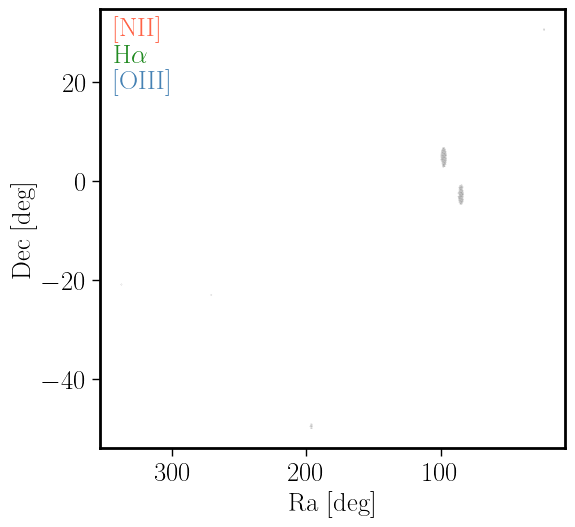

In [257]:
# 637.416/110230.7468
colors=map_plot_DAP_rgb(tab_all, \
                 rgb_key=('flux_pek_6583.45','flux_pek_6562.85','flux_pek_5006.84'), \
                 rgb_scale = (1,1,1), \
                 vmin=-100, vmax=5000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='dapall_dr20',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=1.5)

This cell repeats the RGB visualization for a broad Orion–Rosette region, providing a closer look at one of the main areas used later in the QA examples.


min/max:-100/10000.0


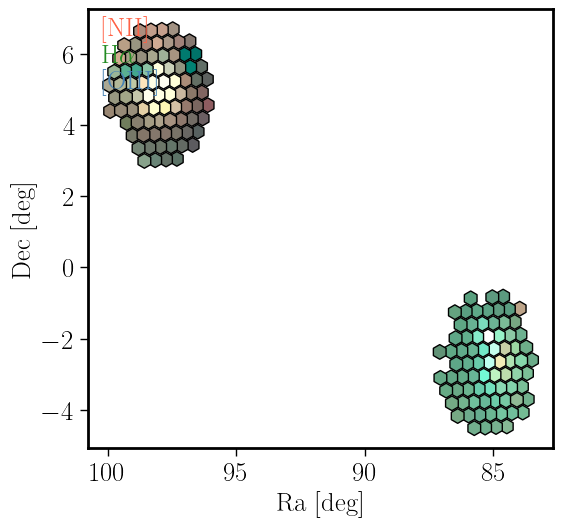

In [258]:
mask_Orion_Rosette = (tab_all['ra']>65) & (tab_all['ra']<110) & (tab_all['dec']>-7) & (tab_all['dec']<10)
colors=map_plot_DAP_rgb(tab_all[mask_Orion_Rosette], \
                 rgb_key=('flux_pek_6583.45','flux_pek_6562.85','flux_pek_5006.84'), \
                 rgb_scale = (10,0.75,1), \
                 vmin=-100, vmax=10000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='dapall_dr20_orion',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=32*1.3)

This panel focuses on the Orion sub-region. The cropped view is useful for comparing morphology and sample selection in a smaller sky area.


min/max:-100/10000.0


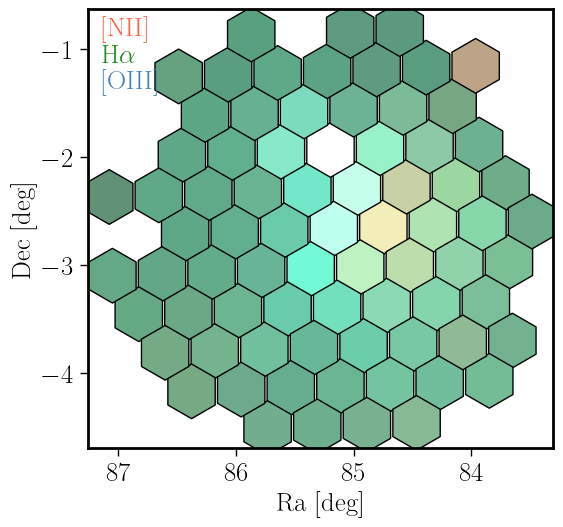

In [259]:
# 637.416/110230.7468
mask_Orion = (tab_all['ra']>65) & (tab_all['ra']<95) & (tab_all['dec']>-7) & (tab_all['dec']<1)
colors=map_plot_DAP_rgb(tab_all[mask_Orion], \
                 rgb_key=('flux_pek_6583.45','flux_pek_6562.85','flux_pek_5006.84'), \
                 rgb_scale = (10,0.75,1), \
                 vmin=-100, vmax=10000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='dapall_dr20_orion',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=32*1.6)

This panel focuses on the Rosette region, which is used in the remaining examples to illustrate how quality-control selections change the retained exposures.


min/max:-100/10000.0


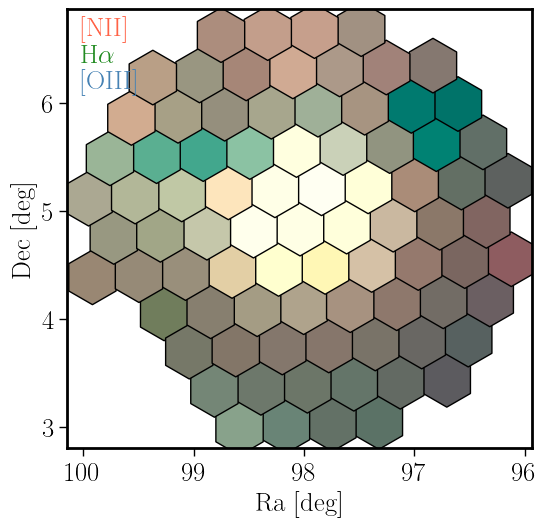

In [260]:
# 637.416/110230.7468
mask_Rosette = (tab_all['ra']>90) & (tab_all['ra']<110) & (tab_all['dec']>0) & (tab_all['dec']<10)
#mask_Orion = (tab_all['ra']>65) & (tab_all['ra']<95) & (tab_all['dec']>-7) & (tab_all['dec']<1)
colors=map_plot_DAP_rgb(tab_all[mask_Rosette], \
                 rgb_key=('flux_pek_6583.45','flux_pek_6562.85','flux_pek_5006.84'), \
                 rgb_scale = (10,0.75,1), \
                 vmin=-100, vmax=10000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='dapall_dr20_rosette',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=32*1.6)

## 7. Generic helper to plot one quantity on the sky

The next helper is a more general sky-map function for plotting a single scalar quantity, such as line flux or a QA-derived selection.


In [261]:
def map_plot_DAP_ax(tab_DAP,ax=None,fig=None,line='flux_Halpha_6562.85', \
                 vmin=0, vmax=0, title=None, filename='junk',\
                 cmap='Spectral', fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,xlab=True,ylab=True, fs=1.0,f_scale=1e7):

    rc.update({'font.size': 19*fs,\
               'font.weight': 900,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : 19*fs,\
               'ytick.labelsize' : 19*fs,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6*fs,\
               'ytick.major.size'        :   6*fs,\
               'xtick.minor.size'        :   3*fs,\
               'ytick.minor.size'        :   3*fs,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X=tab_DAP['ra']
    Y=tab_DAP['dec']
    C=tab_DAP[line]/f_scale    
    if (title== None):
        title=line.replace("_"," ")
        title=line.replace("_"," ")
    if (vmin==vmax):
        vmin=0.00001*np.nanmax(C)
        vmax=np.nanmax(C)

    if (gamma>0):
        norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
        size_sc = sf*35.6/3600
        scat=ax.scatter(X, Y, s=10*sf, c=C, cmap=cmap, norm=norm, rasterized=True, marker='h',edgecolors='black')
    else:

        scat=ax.scatter(X, Y, s=10*sf, c=C, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True, marker='h',edgecolors='black')

    if (xlab == True):
        ax.set_xlabel('Ra [deg]',fontsize=19*fs)
    if (ylab == True):
        ax.set_ylabel('Dec [deg]',fontsize=19*fs)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    props = dict(boxstyle='square', facecolor='white', alpha=0.5)
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.08*fs*(yy[1]-yy[0]),rf'{title}',color='black',\
            bbox=props)

    return scat



## 9. Decode the packed `qa_bitmask`

Each QA metric is stored as a 2-bit field inside the `qa_bitmask` value. The following definitions provide the ordered list of QA fields together with helper functions that decode individual metrics and summarize the overall QA state.


In [263]:


QA_FIELDS: List[str] = [
    "qa_brightstars",
    "qa_sky_brt",
    "qa_absflux",
    "qa_relflux_br",
    "qa_relflux_rz",
    "qa_wavecal_b",
    "qa_wavecal_r",
    "qa_wavecal_z",
    "qa_flatfield",
    "qa_skycont_sub",
    "qa_skyline_sub",
    "qa_dap_npfit",
    "qa_dap_pmfit",
    "qa_visual_drp",
    "qa_visual_dap",
]

BIT_TO_STATE = {
    0b00: "GOOD",
    0b01: "WARNING",
    0b10: "MAJOR ISSUE",
    0b11: "UNDEFINED",
}


def _normalize_bitmask_value(value: object) -> int:
    if value is None:
        raise ValueError("qa_bitmask is None")

    if hasattr(value, "item"):
        try:
            value = value.item()
        except Exception:
            pass

    if isinstance(value, (int,)):
        return int(value)

    text = str(value).strip()
    if not text:
        raise ValueError("qa_bitmask is empty")

    if text.lower().startswith("0x"):
        return int(text, 16)

    return int(text)


def decode_qa_bitmask(bitmask: object, fields: Sequence[str] = QA_FIELDS) -> List[Tuple[str, str]]:
    packed = _normalize_bitmask_value(bitmask)
    decoded: List[Tuple[str, str]] = []

    for index, field in enumerate(fields):
        code = (packed >> (2 * index)) & 0b11
        decoded.append((field, BIT_TO_STATE[code]))

    return decoded


def qa_bitmask_to_label(bitmask: object, fields: Sequence[str] = QA_FIELDS) -> str:
    states = [state for _, state in decode_qa_bitmask(bitmask, fields)]

    if any(state in {"MAJOR ISSUE"} for state in states):
        return "bad"
    if any(state in {"WARNING", "UNDEFINED"} for state in states):
        return "warning"
    return "good"


def qa_bitmask_column_to_label_column(
    qa_bitmask_column,
    fields: Sequence[str] = QA_FIELDS,
) -> List[str]:
    return [qa_bitmask_to_label(value, fields=fields) for value in qa_bitmask_column]


def add_qa_human_column(
    tab_all: Table,
    input_column: str = "qa_bitmask",
    output_column: str = "qa_human",
    overwrite: bool = True,
    fields: Sequence[str] = QA_FIELDS,
) -> Table:
    if input_column not in tab_all.colnames:
        raise KeyError(f"Column {input_column!r} not found in table")

    labels = qa_bitmask_column_to_label_column(tab_all[input_column], fields=fields)

    if output_column in tab_all.colnames and not overwrite:
        raise KeyError(f"Column {output_column!r} already exists and overwrite=False")

    tab_all[output_column] = labels
    return tab_all

QA_STATES = {
    0: "GOOD",
    1: "WARNING",
    2: "MAJOR ISSUE",
    3: "UNDEFINED",
}


def parse_qa_bitmask(bitmask):
    if bitmask is None:
        raise ValueError("qa_bitmask is None")

    if isinstance(bitmask, str):
        return int(bitmask.strip(), 0)

    return int(bitmask)


def extract_qa_parameter(bitmask, field_name):
    value = parse_qa_bitmask(bitmask)
    idx = QA_FIELDS.index(field_name)
    code = (value >> (2 * idx)) & 0b11
    return QA_STATES[code]


## 10. Build a simple overall QA label

This step converts the packed QA bitmask into a compact human-readable classification such as `good`, `warning`, or `bad` for each exposure.


In [264]:
tab_all["qa_human"] = qa_bitmask_column_to_label_column(tab_all["qa_bitmask"])

The map below compares the Rosette-region sample after applying the overall QA classification, making it easy to see which exposures pass the most restrictive selection.


Text(0.5, 1.0, 'Combined QA')

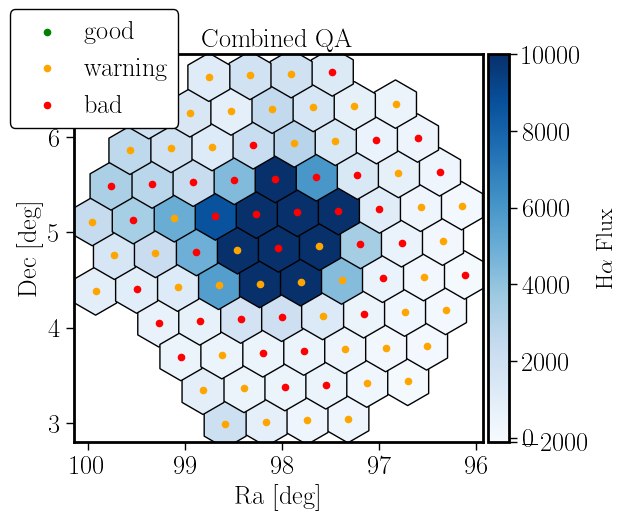

In [265]:
fig, ax = plt.subplots(1,1,figsize=(6,6/1.1))
scat=map_plot_DAP_ax(tab_all[mask_Rosette],ax=ax,fig=fig,line='flux_pek_6562.85', \
                 vmin=-100, vmax=10000, title=r'', filename=filename,\
             cmap='Blues', fsize=3.5, figs_dir='figs',gamma=1,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=32*1.52*2.5,fs=1,\
                        f_scale=1)

mask_good = (tab_all['qa_human'] == 'good') & mask_Rosette
mask_warning = (tab_all['qa_human'] == 'warning') & mask_Rosette
mask_bad = (tab_all['qa_human'] == 'bad') & mask_Rosette

ax.scatter(tab_all['ra'][mask_good], tab_all['dec'][mask_good], color='green', label='good', s=20)
ax.scatter(tab_all['ra'][mask_warning], tab_all['dec'][mask_warning], color='orange', label='warning', s=20)
ax.scatter(tab_all['ra'][mask_bad], tab_all['dec'][mask_bad], color='red', label='bad', s=20    )
# Legend controls (adjust these to move legend)
legend_x = 0.05
legend_y = 1.15

ax.legend(
    loc='upper center',
    bbox_to_anchor=(legend_x, legend_y),  # above axes
    ncol=1,                               # all entries in one row
    frameon=True,
    facecolor='white',
    framealpha=1.0,
    edgecolor='black',
    columnspacing=1.2,
    handletextpad=0.4
)

# optional: leave room for legend above the plot
fig.subplots_adjust(top=0.82, right=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(scat, cax=cax)
cbar.set_label('H$\\alpha$ Flux', fontsize=17)

ax.set_title('Combined QA', fontsize=19)
#ax.scatter()

#tab_all['qa_bitmask']


## 11. Inspect a single QA metric: blue-arm wavelength calibration

In some analyses it is more informative to inspect one QA component directly rather than using a single combined label. This cell decodes the `qa_wavecal_b` field for every exposure.


In [266]:
tab_all["qa_wavecal_b_human"] = [
    extract_qa_parameter(v, "qa_wavecal_b")
    for v in tab_all["qa_bitmask"]
]

The corresponding sky map shows how the blue-arm wavelength-calibration quality is distributed across the Rosette region.


Text(0.5, 1.0, 'Wavelength cal. QA')

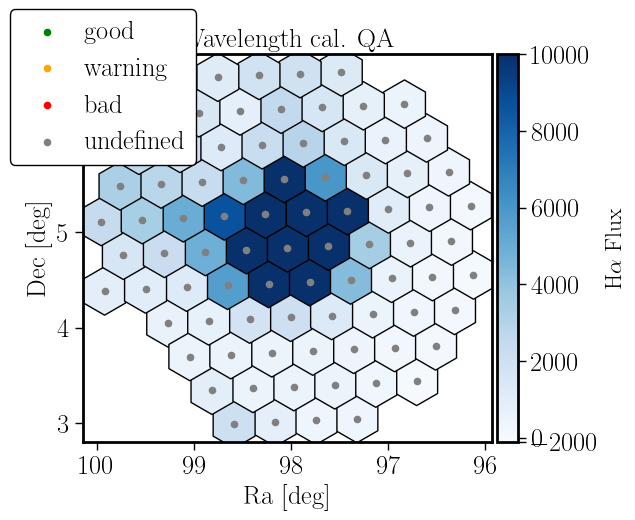

In [267]:
fig, ax = plt.subplots(1,1,figsize=(6,6/1.1))
scat=map_plot_DAP_ax(tab_all[mask_Rosette],ax=ax,fig=fig,line='flux_pek_6562.85', \
                 vmin=-100, vmax=10000, title=r'', filename=filename,\
             cmap='Blues', fsize=3.5, figs_dir='figs',gamma=1,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=32*1.52*2.5,fs=1,\
                        f_scale=1)

mask_good = (tab_all['qa_wavecal_b_human'] == 'GOOD') & mask_Rosette
mask_warning = (tab_all['qa_wavecal_b_human'] == 'WARNING') & mask_Rosette
mask_bad = (tab_all['qa_wavecal_b_human'] == 'BAD') & mask_Rosette
mask_und = (tab_all['qa_wavecal_b_human'] == 'UNDEFINED') & mask_Rosette

ax.scatter(tab_all['ra'][mask_good], tab_all['dec'][mask_good], color='green', label='good', s=20)
ax.scatter(tab_all['ra'][mask_warning], tab_all['dec'][mask_warning], color='orange', label='warning', s=20)
ax.scatter(tab_all['ra'][mask_bad], tab_all['dec'][mask_bad], color='red', label='bad', s=20    )
ax.scatter(tab_all['ra'][mask_und], tab_all['dec'][mask_und], color='gray', label='undefined', s=20    )    
# Legend controls (adjust these to move legend)
legend_x = 0.05
legend_y = 1.15

ax.legend(
    loc='upper center',
    bbox_to_anchor=(legend_x, legend_y),  # above axes
    ncol=1,                               # all entries in one row
    frameon=True,
    facecolor='white',
    framealpha=1.0,
    edgecolor='black',
    columnspacing=1.2,
    handletextpad=0.4
)

# optional: leave room for legend above the plot
fig.subplots_adjust(top=0.82, right=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(scat, cax=cax)
cbar.set_label('H$\\alpha$ Flux', fontsize=17)

ax.set_title('Wavelength cal. QA', fontsize=19)
#ax.scatter()

#tab_all['qa_bitmask']

## 12. Inspect a second QA metric: sky brightness

This example repeats the same procedure for the `qa_sky_brt` field, illustrating how individual QA dimensions can be explored independently.


In [268]:
tab_all["qa_sky_brt_human"] = [
    extract_qa_parameter(v, "qa_sky_brt")
    for v in tab_all["qa_bitmask"]
]

The final map highlights the exposures classified as good in sky brightness, which can be useful for selecting subsets tailored to a specific science case.


Text(0.5, 1.0, 'Sky Brightness QA')

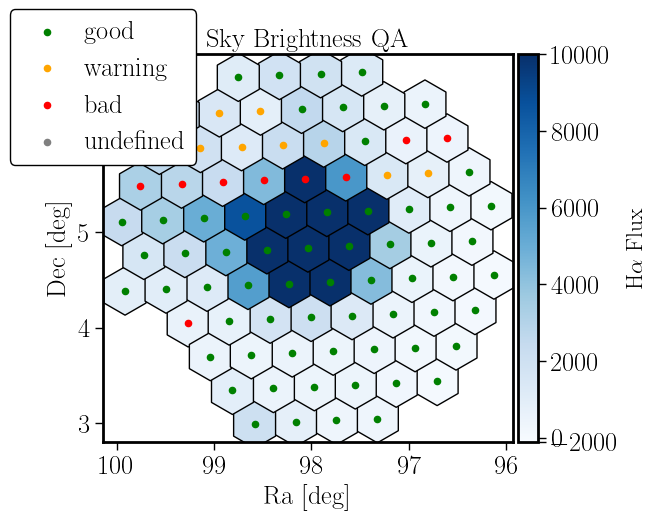

In [269]:
fig, ax = plt.subplots(1,1,figsize=(6,6/1.1))
scat=map_plot_DAP_ax(tab_all[mask_Rosette],ax=ax,fig=fig,line='flux_pek_6562.85', \
                 vmin=-100, vmax=10000, title=r'', filename=filename,\
             cmap='Blues', fsize=3.5, figs_dir='figs',gamma=1,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=32*1.52*2.5,fs=1,\
                        f_scale=1)

mask_good = (tab_all['qa_sky_brt_human'] == 'GOOD') & mask_Rosette
mask_warning = (tab_all['qa_sky_brt_human'] == 'WARNING') & mask_Rosette
mask_bad = (tab_all['qa_sky_brt_human'] == 'MAJOR ISSUE') & mask_Rosette
mask_und = (tab_all['qa_sky_brt_human'] == 'UNDEFINED') & mask_Rosette
ax.scatter(tab_all['ra'][mask_good], tab_all['dec'][mask_good], color='green', label='good', s=20)
ax.scatter(tab_all['ra'][mask_warning], tab_all['dec'][mask_warning], color='orange', label='warning', s=20)
ax.scatter(tab_all['ra'][mask_bad], tab_all['dec'][mask_bad], color='red', label='bad', s=20    )
ax.scatter(tab_all['ra'][mask_und], tab_all['dec'][mask_und], color='gray', label='undefined', s=20    )    
# Legend controls (adjust these to move legend)
legend_x = 0.0
legend_y = 1.15

ax.legend(
    loc='upper center',
    bbox_to_anchor=(legend_x, legend_y),  # above axes
    ncol=1,                               # all entries in one row
    frameon=True,
    facecolor='white',
    framealpha=1.0,
    edgecolor='black',
    columnspacing=1.2,
    handletextpad=0.4
)

# optional: leave room for legend above the plot
fig.subplots_adjust(top=0.82, right=0.85)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(scat, cax=cax)
cbar.set_label('H$\\alpha$ Flux', fontsize=17)

ax.set_title('Sky Brightness QA', fontsize=19)
#ax.scatter()

#tab_all['qa_bitmask']